Loading the dataset: CIFAR-10

We will use the CIFAR-10 dataset for training and testing (https://www.cs.toronto.edu/~kriz/cifar.html).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential

from sklearn.metrics import confusion_matrix
import seaborn as sns

from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

Visualize the data

In [3]:
#print(x_train.shape)

num_classes = 10

#fig = plt.figure(figsize=(10*1/2.54, 10*1/2.54))

#for idx_class in range(num_classes):

  #all_idx = np.where(y_train.flatten() == idx_class)[0]

  # random selection of 10 image of each category
  #rand_idx = np.random.choice(all_idx, size=10, replace=False)
  #selected = x_train[rand_idx]

  #plt.figure(figsize=(10, 10))

  #for i in range(10):
  #  plt.subplot(1, 10, i+1)
  #  plt.imshow(selected[i])
  #  plt.tight_layout()

  #plt.show()

Data normalization

In [4]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


Prepare the labels

In [5]:
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(y_train.shape)
print(y_test.shape)

(50000, 10)
(10000, 10)


Define the first model

In [6]:
input_shape = (32, 32, 3)

#my_reg = keras.regularizers.l2(0.0001)

model1 = Sequential(
    [
        keras.Input(shape=input_shape),

        # data augmentation
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(0.125, 0.125),

        # block 1
        layers.Conv2D(32, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.15),

        # block 2
        layers.Conv2D(64, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.20),

        # block 3
        layers.Conv2D(128, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.30),

        layers.Flatten(),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),

        layers.Dropout(0.40),

        layers.Dense(num_classes, activation="softmax")



        #keras.Input(shape=input_shape),
        #layers.Conv2D(32, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001)),
        #layers.Conv2D(32, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001)),

        #layers.MaxPooling2D(pool_size=(2,2)),

        #layers.Dropout(0.25),

        #layers.Conv2D(64, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001)),
        #layers.Conv2D(64, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001)),

        #layers.MaxPooling2D(pool_size=(2,2)),

        #layers.Dropout(0.25),

        #layers.Conv2D(128, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001)),
        #layers.Conv2D(128, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001)),

        #layers.MaxPooling2D(pool_size=(2,2)),

        #layers.Dropout(0.25),

        # fully connected
        #layers.Flatten(),

        #layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001)),

        #layers.Dropout(0.25),

        #layers.Dense(num_classes, activation="softmax")
    ]
)

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)


Compile the model

In [7]:
import time

#my_SGD = keras.optimizers.SGD(learning_rate=0.001)
#my_Adam = keras.optimizers.Adam(learning_rate=0.005)
#my_SGD = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
#model1.compile(loss='categorical_crossentropy', optimizer=my_SGD, metrics=['accuracy'])

start = time.time()
history = model1.fit(x_train, y_train, batch_size=512, epochs=100, validation_split=0.1, callbacks=[early_stop])
end = time.time()

total_time = end - start
print("Training time:", total_time, "seconds")

epochs = len(history.history['loss'])
avg_time = total_time / epochs
print("Average time per epoch:", avg_time, "seconds")

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - accuracy: 0.3003 - loss: 2.2913 - val_accuracy: 0.0950 - val_loss: 2.6776
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.4680 - loss: 1.4887 - val_accuracy: 0.1320 - val_loss: 3.0253
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.5548 - loss: 1.2420 - val_accuracy: 0.1704 - val_loss: 3.0327
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.6066 - loss: 1.0935 - val_accuracy: 0.2238 - val_loss: 2.8238
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.6452 - loss: 0.9888 - val_accuracy: 0.4012 - val_loss: 1.9195
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.6830 - loss: 0.8966 - val_accuracy: 0.6854 - val_loss: 0.9077
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.6997 - loss: 0.8560 - val_accuracy: 0.7220 - val_loss: 0.8275
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.7199 - loss: 0.7961 - val_accuracy:

In [11]:
print(history.history.keys())

print("Train accuracy:", history.history["accuracy"][-1])
print("Validation accuracy:", history.history["val_accuracy"][-1])

print("Train loss:", history.history["loss"][-1])
print("Validation loss:", history.history["val_loss"][-1])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Train accuracy: 0.860955536365509
Validation accuracy: 0.857200026512146
Train loss: 0.3981960415840149
Validation loss: 0.44374117255210876


Evaluate the model

Test accuracy: 0.8474000096321106
Test loss: 0.455658495426178
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


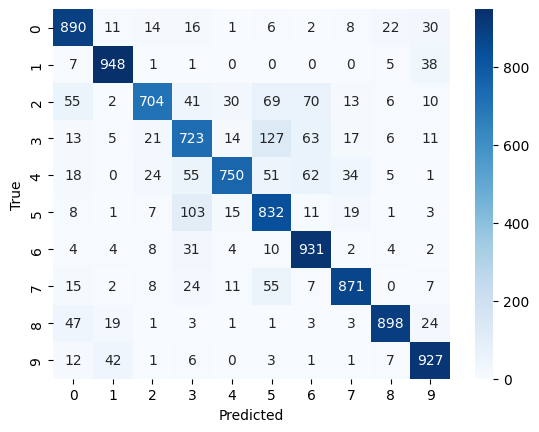

In [12]:
score = model1.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", score[1])
print("Test loss:", score[0])

y_test_pred_prob = model1.predict(x_test)
y_test_pred = y_test_pred_prob.argmax(axis=1)

conf_matr = confusion_matrix(y_test.argmax(axis=1), y_test_pred)

sns.heatmap(conf_matr, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Save the model to file#

In [13]:
import os

#print("Working directory:", os.getcwd())
#print("Files here:", os.listdir())

# save the trained model
model1.save("cifar10.model14.keras")